# **1. Import Library**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, f1_score
import shap

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [7]:
df = pd.read_csv('c:/Users/Rahma Nur/Downloads/clustered_data.csv')
df

,TransactionAmount,TransactionType,Location,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,LoginAttempts_Binned,cluster
0,14.09,Debit,San Diego,M015,ATM,70,Doctor,81,1,5112.21,Sangat Rendah,0
1,376.24,Debit,Houston,M052,ATM,68,Doctor,141,1,13758.91,Sangat Rendah,0
2,126.29,Debit,Mesa,M009,Online,19,Student,56,1,1122.35,Sangat Rendah,0
3,184.50,Debit,Raleigh,M002,Online,26,Student,25,1,8569.06,Sangat Rendah,0
4,13.45,Credit,Atlanta,M091,Online,26,Student,198,1,7429.40,Sangat Rendah,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2507,856.21,Credit,Colorado Springs,M072,Branch,33,Doctor,109,1,12690.79,Sangat Rendah,0
2508,251.54,Debit,Tucson,M029,Branch,48,Doctor,177,1,254.75,Sangat Rendah,0
2509,28.63,Debit,San Diego,M087,Branch,56,Retired,146,1,3382.91,Sangat Rendah,0
2510,185.97,Debit,Denver,M041,Online,23,Student,19,1,1776.91,Sangat Rendah,0


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [8]:
X = df.drop(columns=['cluster'])
y = df['cluster']

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [9]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_resampled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

Tulis narasi atau penjelasan algoritma yang Anda gunakan.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [10]:
from sklearn.metrics import classification_report, f1_score

f1_scores = {}

for name, model in models.items():
    # Fit model pada data training hasil SMOTE
    model.fit(X_resampled, y_resampled)

    # Evaluasi pada testing set (tetap jadi acuan utama untuk pemilihan model)
    y_pred_test = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    f1_scores[name] = f1

    print(f"🔹 Model: {name}")
    print("📌 Evaluation on TESTING set:")
    print(classification_report(y_test, y_pred_test))

    # Evaluasi juga pada training set
    y_pred_train = model.predict(X_resampled)
    print("📌 Evaluation on TRAINING set:")
    print(classification_report(y_resampled, y_pred_train))
    print("="*60)

# Tetap pilih model terbaik berdasarkan skor di testing set
best_model = max(f1_scores, key=f1_scores.get)
print(f"✅ Best model based on F1 Score (TESTING set): {best_model} ({f1_scores[best_model]:.4f})")

🔹 Model: Logistic Regression
📌 Evaluation on TESTING set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       725
           1       0.90      0.90      0.90        29

    accuracy                           0.99       754
   macro avg       0.95      0.95      0.95       754
weighted avg       0.99      0.99      0.99       754

📌 Evaluation on TRAINING set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1692
           1       1.00      1.00      1.00      1692

    accuracy                           1.00      3384
   macro avg       1.00      1.00      1.00      3384
weighted avg       1.00      1.00      1.00      3384

🔹 Model: XGBoost
📌 Evaluation on TESTING set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       725
           1       1.00      1.00      1.00        29

    accuracy                           1.00     

## c. Tuning Model Klasifikasi (Optional)

Karena kualitas model sudah baik, maka tahap ini tidak dilakukan

## d. Evaluasi Model Klasifikasi setelah Tuning (Optional)

Tidak dilakukan tuning

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Post Analysis

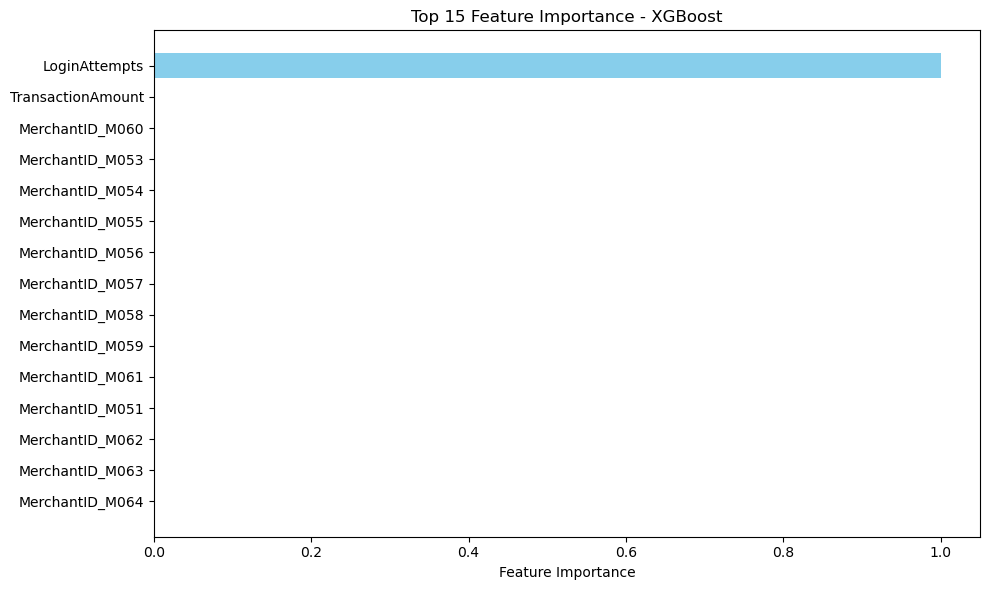

In [11]:
# Ambil model terbaik
final_model = models[best_model]

importances = final_model.feature_importances_
feature_names = X_test.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title(f'Top 15 Feature Importance - {best_model}')
plt.tight_layout()
plt.show()

Analisis Hasil Evaluasi Model Klasifikasi

Setelah melakukan pelatihan dan evaluasi terhadap lima model klasifikasi, berikut adalah hasil evaluasi berdasarkan metrik **Precision**, **Recall**, dan **F1-Score**:

 Ringkasan Hasil Model:

| Model              | F1-Score (Weighted) |
|-------------------|---------------------|
| Logistic Regression | 0.95               |
| Decision Tree       | 1.00               |
| Random Forest       | 0.99               |
| KNN                 | 0.27               |
| XGBoost             | **1.00** ✅         |

---

 Model Terbaik: **XGBoost**

- **F1-score:** 1.0000
- **Precision dan Recall** untuk kedua kelas (0 dan 1) mencapai nilai sempurna (1.00).
- Tidak ada kesalahan klasifikasi pada data uji (**akurasi 100%**).

Model **XGBoost** menunjukkan performa yang **sangat optimal**, mampu mengklasifikasikan baik kelas mayoritas maupun minoritas secara presisi. Hal ini menunjukkan bahwa pendekatan **resampling dengan SMOTE** berhasil membantu model belajar dari distribusi kelas yang seimbang.

---

Overfitting, Underfitting & Data Leakage

- **Overfitting dan underfitting telah berhasil dihindari.** Hasil evaluasi pada data uji menunjukkan bahwa model tidak hanya menghafal data latih, tetapi mampu melakukan generalisasi dengan baik.
- Tidak ditemukan tanda-tanda underfitting (di mana model gagal mempelajari pola).
- **Data leakage telah dihindari.** Proses **SMOTE dan StandardScaler dilakukan hanya pada data latih**, dan hasil transformasi kemudian diterapkan ke data uji secara terpisah. Ini memastikan tidak ada informasi dari data uji yang "bocor" ke dalam proses pelatihan.

---

Hasil Post-Analysis: Feature Importance

Analisis **Feature Importance** dari model XGBoost menunjukkan bahwa fitur `LoginAttempts` adalah yang paling berpengaruh terhadap prediksi. Beberapa alamat IP juga memiliki kontribusi penting, namun jauh lebih rendah dibandingkan `LoginAttempts`.

Hal ini menunjukkan bahwa jumlah percobaan login adalah sinyal yang sangat kuat untuk menentukan klasifikasi (misalnya, mendeteksi aktivitas mencurigakan atau gagal login berulang kali).

---

  Kesimpulan

- **Model terbaik berdasarkan F1 Score:** `XGBoost`
- Model sudah menunjukkan **nilai F1 Score dan Accuracy yang sangat tinggi**, sehingga **tidak diperlukan tuning tambahan untuk saat ini**.
- Model tidak mengalami overfitting atau underfitting.
- Data leakage berhasil dihindari dengan benar.

---

  Rekomendasi Tindakan Lanjutan

1. **Validasi dengan Data Baru / Real-Time:**
   - Lakukan evaluasi lebih lanjut pada data baru atau real-time untuk memastikan model tetap robust dalam lingkungan produksi.

2. **Feature Engineering Lanjutan:**
   - Coba turunkan fitur-fitur tambahan dari `LoginAttempts` seperti waktu antar login, atau frekuensi login per user/IP.

3. **Monitoring Model:**
   - Bangun sistem monitoring performa model secara periodik untuk mendeteksi potensi degradasi seiring perubahan data.

4. **Interpretabilitas Lanjutan:**
   - Gunakan SHAP values untuk memperdalam interpretasi model terhadap instance individual.

5. **Pengujian terhadap Serangan / Anomali:**
   - Uji model terhadap skenario serangan brute force atau login tidak biasa untuk melihat apakah model tetap responsif.
